In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Clean up raw data

Read in tsvs, assign headers

Don't need column 0

In [17]:
pycashier_header = ['UMI', 'cell', 'lineage']
softmi = pd.read_table('SoftMi.cell_record_labeled.barcode.tsv', usecols=[1, 2, 3], names=pycashier_header)
softnon = pd.read_table('SoftNon.cell_record_labeled.barcode.tsv', usecols=[1, 2, 3], names=pycashier_header)
stiffmi = pd.read_table('StiffMi.cell_record_labeled.barcode.tsv', usecols=[1, 2, 3], names=pycashier_header)
stiffnon = pd.read_table('StiffNon.cell_record_labeled.barcode.tsv', usecols=[1, 2, 3], names=pycashier_header)

In [18]:
softmi

,UMI,cell,lineage
0,AAAAGGCATATA,AACATAAACACAAGAG,TAAATCGCTAGTAATCATAG
1,AAAATGGTGTTT,CTTGGACATCATCTTA,GGGCAGGTTCATATGGTAG
2,AAACCCATAGTT,CTCCACAGTAGCCATG,AATAGAGTAGGTCCAGCGTT
3,AAACGAGAGCCT,AGAAGTACAAAATGGT,GATCAGAAAATTAGCGTCTT
4,AAAGGCCAAGTT,CTACGGGTGTTTGCAA,AAATGCGCCGTGCAACTAAG
...,...,...,...
65894,CTTTATGTCACG,TTTGTTGTCCGTCACT,GTGAATTTCCTGGGGGATTG
65895,CTTTATGTCACG,TTTGTTGTCCGTCACT,GTGAATTTCCTGGGGGATTG
65896,AAAGTTAGTTGC,TTTGTTGTCGACATCA,GTGAATTTCCTGGGGGATTG
65897,TGTTGCGCAAAA,TTTGTTGTCTAACGGT,TTTACATCCAGCTTTAG


Combine tables

In [19]:
combined_sample = pd.concat([softmi, softnon, stiffmi, stiffnon])
combined_sample

,UMI,cell,lineage
0,AAAAGGCATATA,AACATAAACACAAGAG,TAAATCGCTAGTAATCATAG
1,AAAATGGTGTTT,CTTGGACATCATCTTA,GGGCAGGTTCATATGGTAG
2,AAACCCATAGTT,CTCCACAGTAGCCATG,AATAGAGTAGGTCCAGCGTT
3,AAACGAGAGCCT,AGAAGTACAAAATGGT,GATCAGAAAATTAGCGTCTT
4,AAAGGCCAAGTT,CTACGGGTGTTTGCAA,AAATGCGCCGTGCAACTAAG
...,...,...,...
77783,AGAGCGCCACTT,TTTGTTGGTCTCACAA,AGGAGGGGTGCGGCGCCGTG
77784,GAGGGCCTAAGC,TTTGTTGGTGACTGAG,TCACATGGCGCAATCGTTCG
77785,CCTTGTGATACA,TTTGTTGTCTCCGAGG,GTGAATTTCCTGGGGGATTG
77786,GCTCACTAAGCA,TTTGTTGTCTGTAACG,CCGGCCGGTTATGCTGTTTA


Cull tables to only include cell barcodes from our cellranger output - barcodes.tsv

In [20]:
cells_used = pd.read_table('barcodes.tsv', header=None)[0].to_list()
cells_used

['AAACCCACACGTAACT-1',
 'AAACGCTAGCACTAGG-1',
 'AAACGCTCATTGGCAT-1',
 'AAACGCTGTAATGATG-1',
 'AAACGCTTCACATACG-1',
 'AAAGGATGTCCCGCAA-1',
 'AAAGGTAAGGTGTGAC-1',
 'AAAGGTACATGACGAG-1',
 'AAAGGTAGTCTACATG-1',
 'AAAGGTATCGTGCTCT-1',
 'AAAGTGAAGTATTAGG-1',
 'AAATGGAAGTAAGGGA-1',
 'AAATGGAAGTATAGGT-1',
 'AAATGGACATCAGCTA-1',
 'AACAACCAGTTCTCTT-1',
 'AACAACCCACCAGTTA-1',
 'AACAAGAAGTGAGCCA-1',
 'AACACACCAATAACGA-1',
 'AACAGGGAGTTGTCGT-1',
 'AACAGGGGTTCGGTAT-1',
 'AACAGGGTCGCCTAGG-1',
 'AACCACACAGAGAGGG-1',
 'AACCATGAGTTACGTC-1',
 'AACCCAAAGTCGGCAA-1',
 'AACCCAAGTTCGGTTA-1',
 'AACCCAATCTGCGGGT-1',
 'AACCTGACACTAGTAC-1',
 'AACCTGATCTACCACC-1',
 'AACCTTTTCATCGCTC-1',
 'AACGGGATCTCGGCTT-1',
 'AACGTCATCTAGTGAC-1',
 'AACTTCTCAAGGTCTT-1',
 'AACTTCTCAGAACTTC-1',
 'AAGAACAAGATGACCG-1',
 'AAGACAACAGGATCTT-1',
 'AAGACAAGTGATGTAA-1',
 'AAGACAATCCACGGAC-1',
 'AAGACTCCAGCTGTCG-1',
 'AAGATAGAGAAATCCA-1',
 'AAGATAGCAGACCATT-1',
 'AAGCATCGTACCTAAC-1',
 'AAGCATCGTCGCGTCA-1',
 'AAGCATCTCGCCTTTG-1',
 'AAGCCATAG

Remove the numbers from the end of the cell barcodes

In [21]:
for i in range(len(cells_used)):
    cells_used[i] = cells_used[i][:-2]
cells_used

['AAACCCACACGTAACT',
 'AAACGCTAGCACTAGG',
 'AAACGCTCATTGGCAT',
 'AAACGCTGTAATGATG',
 'AAACGCTTCACATACG',
 'AAAGGATGTCCCGCAA',
 'AAAGGTAAGGTGTGAC',
 'AAAGGTACATGACGAG',
 'AAAGGTAGTCTACATG',
 'AAAGGTATCGTGCTCT',
 'AAAGTGAAGTATTAGG',
 'AAATGGAAGTAAGGGA',
 'AAATGGAAGTATAGGT',
 'AAATGGACATCAGCTA',
 'AACAACCAGTTCTCTT',
 'AACAACCCACCAGTTA',
 'AACAAGAAGTGAGCCA',
 'AACACACCAATAACGA',
 'AACAGGGAGTTGTCGT',
 'AACAGGGGTTCGGTAT',
 'AACAGGGTCGCCTAGG',
 'AACCACACAGAGAGGG',
 'AACCATGAGTTACGTC',
 'AACCCAAAGTCGGCAA',
 'AACCCAAGTTCGGTTA',
 'AACCCAATCTGCGGGT',
 'AACCTGACACTAGTAC',
 'AACCTGATCTACCACC',
 'AACCTTTTCATCGCTC',
 'AACGGGATCTCGGCTT',
 'AACGTCATCTAGTGAC',
 'AACTTCTCAAGGTCTT',
 'AACTTCTCAGAACTTC',
 'AAGAACAAGATGACCG',
 'AAGACAACAGGATCTT',
 'AAGACAAGTGATGTAA',
 'AAGACAATCCACGGAC',
 'AAGACTCCAGCTGTCG',
 'AAGATAGAGAAATCCA',
 'AAGATAGCAGACCATT',
 'AAGCATCGTACCTAAC',
 'AAGCATCGTCGCGTCA',
 'AAGCATCTCGCCTTTG',
 'AAGCCATAGACGCCAA',
 'AAGCGAGTCACGTCCT',
 'AAGTCGTTCCAGCTCT',
 'AAGTCGTTCGGTTAGT',
 'AAGTGAAAGAG

Remove all cell lineages that aren't in our list - cell barcodes

In [22]:
combined_sample= combined_sample[[cell in cells_used for cell in combined_sample['cell']]]
combined_sample


,UMI,cell,lineage
554,AAACCAGAACCG,AAACCCACACGTAACT,ATCTGGAAGTCGGGATGTGG
555,AAATATGGAGCA,AAACCCACACGTAACT,GTCGGGATGTGG
556,AACATTTTGAAT,AAACCCACACGTAACT,ATCTGGAAGTCGGGATGTGG
557,AACTCTTAAGCG,AAACCCACACGTAACT,ATCTGGAAGTCGGGATGTGG
558,AACTTAAACTTA,AAACCCACACGTAACT,ATCTGGAAGTCGGGATGTGG
...,...,...,...
77775,TTCTAGTTCATA,TTTGTTGGTACTCGTA,TTTTAAGGTTCAGATTAATT
77776,TTCTAGTTCATA,TTTGTTGGTACTCGTA,GGTTCAGATTAATT
77777,TTTCTAACTCTT,TTTGTTGGTACTCGTA,GTTCAGATTAATT
77778,TTTTGTGATGAA,TTTGTTGGTACTCGTA,TTTTAAGGTTCAGATTAATT


Combine rows with the same UMI and cell barcode - use the longer of the two lineages

In [23]:
def combine_umi_duplicates(group):
    longest_lineage = group.loc[group['lineage'].str.len().idxmax(), 'lineage']
    return pd.Series({
        'UMI':group['UMI'].iloc[0],
        'cell':group['cell'].iloc[0],
        'lineage':longest_lineage
    })

In [24]:
combined_sample = combined_sample.groupby(['UMI', 'cell']).apply(combine_umi_duplicates).reset_index(drop=True)

/tmp/ipykernel_1793809/1284379585.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  combined_sample = combined_sample.groupby(['UMI', 'cell']).apply(combine_umi_duplicates).reset_index(drop=True)


In [25]:
combined_sample

,UMI,cell,lineage
0,AAAAAAACACAC,GCAACATAGCCTGTGC,TTCCTGGGGGATTG
1,AAAAAAACGAAT,ATGGAGGTCATAGCAC,GGGAACTCAGATGATTGGAA
2,AAAAAAACGTAC,GCATCTCTCTGCAGCG,CCGGCCGGTTATGCTGTTTA
3,AAAAAAAGCATA,TGATTTCAGCACTAGG,AATAGAGTAGGTCCAGCGTT
4,AAAAAACAGGGC,GGTAGAGCAATTCTTC,AATAGAGTAGGTCCAGCGTT
...,...,...,...
189805,TTTTTTTTTTTT,CTCCACATCCACATAG,GGTTCAGATTAATT
189806,TTTTTTTTTTTT,GGGTTTACAGTAACGG,AATAGAGTAGGTCCAGCGTT
189807,TTTTTTTTTTTT,TATCAGGAGCCTGACC,GTGAATTTCCTGGGGGATTG
189808,TTTTTTTTTTTT,TGATGGTTCCGTGTAA,CTTTATATCACGAGATAGAC


In [26]:
combined_sample.loc[:, 'length'] = [len(i) for i in combined_sample['lineage']]
combined_sample

,UMI,cell,lineage,length
0,AAAAAAACACAC,GCAACATAGCCTGTGC,TTCCTGGGGGATTG,14
1,AAAAAAACGAAT,ATGGAGGTCATAGCAC,GGGAACTCAGATGATTGGAA,20
2,AAAAAAACGTAC,GCATCTCTCTGCAGCG,CCGGCCGGTTATGCTGTTTA,20
3,AAAAAAAGCATA,TGATTTCAGCACTAGG,AATAGAGTAGGTCCAGCGTT,20
4,AAAAAACAGGGC,GGTAGAGCAATTCTTC,AATAGAGTAGGTCCAGCGTT,20
...,...,...,...,...
189805,TTTTTTTTTTTT,CTCCACATCCACATAG,GGTTCAGATTAATT,14
189806,TTTTTTTTTTTT,GGGTTTACAGTAACGG,AATAGAGTAGGTCCAGCGTT,20
189807,TTTTTTTTTTTT,TATCAGGAGCCTGACC,GTGAATTTCCTGGGGGATTG,20
189808,TTTTTTTTTTTT,TGATGGTTCCGTGTAA,CTTTATATCACGAGATAGAC,20


# Expand, Collapse, and Consolidate lineages

### 1. Expand lineages

In [27]:
short_lins = np.unique(combined_sample.loc[combined_sample['length'] < 20, 'lineage'])
n20_lins = np.unique(combined_sample.loc[combined_sample['length'] == 20, 'lineage'])

In [28]:
expand_dict = {}

for lineage in short_lins:
    for compare in n20_lins:
        if lineage in compare:
            expand_dict[lineage] = compare

expand_dict

{'AAAAAACCACTTCGG': 'CCTATAAAAAACCACTTCGG',
 'AAAAACCACTTCGG': 'CCTATAAAAAACCACTTCGG',
 'AAAACCACTTCGG': 'CCTATAAAAAACCACTTCGG',
 'AAAACTCGCGGAAAGCT': 'AAAACTCGCGGAAAGCTTAT',
 'AAAACTGGCTGTCAC': 'GTACCAAAACTGGCTGTCAC',
 'AAAAGGAGAAA': 'CCGCGGCAGAAAAGGAGAAA',
 'AAAATCTATCATTCA': 'TTTTTAAAATCTATCATTCA',
 'AAACATTGTGTTGGTGC': 'ATTAAACATTGTGTTGGTGC',
 'AAACGCCCTTAGGGCTCG': 'TGAAACGCCCTTAGGGCTCG',
 'AAACGGATCTTTGT': 'GTGTAGAAACGGATCTTTGT',
 'AAACTCGCGGAAAGCTTAG': 'GAAACTCGCGGAAAGCTTAG',
 'AAACTGGCTGTCAC': 'GTACCAAAACTGGCTGTCAC',
 'AAAGAAGCATGGGATG': 'GTGGAAAGAAGCATGGGATG',
 'AAAGAATGTACGG': 'CTCGTGTAAAGAATGTACGG',
 'AAAGGAGAAA': 'CCGCGGCAGAAAAGGAGAAA',
 'AAAGGATTATTG': 'TGCATTAGAAAGGATTATTG',
 'AAAGTATGTACGG': 'CTTGTGTAAAGTATGTACGG',
 'AAAGTCTCGACAGA': 'TGCAGCAAAGTCTCGACAGA',
 'AAATCAATCCCAATA': 'GCGTTAAATCAATCCCAATA',
 'AAATCGGCGG': 'GGATGACGGCAAATCGGCGG',
 'AAATGAAGCTAGG': 'TCCCACCAAATGAAGCTAGG',
 'AAATGCGCCGTGCAACTAA': 'AAATGCGCCGTGCAACTAAG',
 'AAATGGGTTAGG': 'ATCGGCCGAAATGGGTTAGG',
 'AA

In [29]:
combined_sample.loc[:, 'expanded_lineage'] = combined_sample.loc[:, 'lineage'].copy()
combined_sample.loc[:, 'expanded_lineage'].replace(expand_dict, inplace=True)
combined_sample

/tmp/ipykernel_1793809/812158358.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_sample.loc[:, 'expanded_lineage'].replace(expand_dict, inplace=True)


,UMI,cell,lineage,length,expanded_lineage
0,AAAAAAACACAC,GCAACATAGCCTGTGC,TTCCTGGGGGATTG,14,TTGAATTTCCTGGGGGATTG
1,AAAAAAACGAAT,ATGGAGGTCATAGCAC,GGGAACTCAGATGATTGGAA,20,GGGAACTCAGATGATTGGAA
2,AAAAAAACGTAC,GCATCTCTCTGCAGCG,CCGGCCGGTTATGCTGTTTA,20,CCGGCCGGTTATGCTGTTTA
3,AAAAAAAGCATA,TGATTTCAGCACTAGG,AATAGAGTAGGTCCAGCGTT,20,AATAGAGTAGGTCCAGCGTT
4,AAAAAACAGGGC,GGTAGAGCAATTCTTC,AATAGAGTAGGTCCAGCGTT,20,AATAGAGTAGGTCCAGCGTT
...,...,...,...,...,...
189805,TTTTTTTTTTTT,CTCCACATCCACATAG,GGTTCAGATTAATT,14,TTTTTAGGTTCAGATTAATT
189806,TTTTTTTTTTTT,GGGTTTACAGTAACGG,AATAGAGTAGGTCCAGCGTT,20,AATAGAGTAGGTCCAGCGTT
189807,TTTTTTTTTTTT,TATCAGGAGCCTGACC,GTGAATTTCCTGGGGGATTG,20,GTGAATTTCCTGGGGGATTG
189808,TTTTTTTTTTTT,TGATGGTTCCGTGTAA,CTTTATATCACGAGATAGAC,20,CTTTATATCACGAGATAGAC


In [30]:
print(len(np.unique(combined_sample.loc[:, 'lineage'])), 'unique lineages reduced to', len(np.unique(combined_sample.loc[:, 'expanded_lineage'])), 'after expanding')

6565 unique lineages reduced to 3864 after expanding


### 2. Collapse lineages

Let's see how many short lineages we still have after expansion:

In [31]:
expanded_lineage_lengths = np.array([len(lineage) for lineage in combined_sample.loc[:, 'expanded_lineage']])
n_unique_pre_collapse = len(np.unique(combined_sample.loc[:, 'expanded_lineage']))

Text(0, 0.5, 'Count')

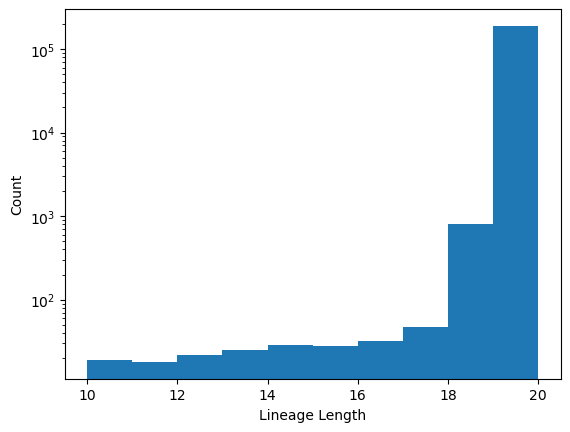

In [32]:
plt.hist(expanded_lineage_lengths,
            bins=range(
                expanded_lineage_lengths.min(), 
                expanded_lineage_lengths.max()+1),
            log=True
            )
plt.xlabel('Lineage Length')
plt.ylabel('Count')

In [33]:
combined_sample = combined_sample.loc[expanded_lineage_lengths == 20,:]
combined_sample

,UMI,cell,lineage,length,expanded_lineage
0,AAAAAAACACAC,GCAACATAGCCTGTGC,TTCCTGGGGGATTG,14,TTGAATTTCCTGGGGGATTG
1,AAAAAAACGAAT,ATGGAGGTCATAGCAC,GGGAACTCAGATGATTGGAA,20,GGGAACTCAGATGATTGGAA
2,AAAAAAACGTAC,GCATCTCTCTGCAGCG,CCGGCCGGTTATGCTGTTTA,20,CCGGCCGGTTATGCTGTTTA
3,AAAAAAAGCATA,TGATTTCAGCACTAGG,AATAGAGTAGGTCCAGCGTT,20,AATAGAGTAGGTCCAGCGTT
4,AAAAAACAGGGC,GGTAGAGCAATTCTTC,AATAGAGTAGGTCCAGCGTT,20,AATAGAGTAGGTCCAGCGTT
...,...,...,...,...,...
189805,TTTTTTTTTTTT,CTCCACATCCACATAG,GGTTCAGATTAATT,14,TTTTTAGGTTCAGATTAATT
189806,TTTTTTTTTTTT,GGGTTTACAGTAACGG,AATAGAGTAGGTCCAGCGTT,20,AATAGAGTAGGTCCAGCGTT
189807,TTTTTTTTTTTT,TATCAGGAGCCTGACC,GTGAATTTCCTGGGGGATTG,20,GTGAATTTCCTGGGGGATTG
189808,TTTTTTTTTTTT,TGATGGTTCCGTGTAA,CTTTATATCACGAGATAGAC,20,CTTTATATCACGAGATAGAC


In [34]:
print(n_unique_pre_collapse, 'unique barcodes reduced to', len(np.unique(combined_sample.loc[:, 'expanded_lineage'])), 'after collapsing')

3864 unique barcodes reduced to 3501 after collapsing


In [35]:
np.unique(combined_sample.loc[:, 'cell']).shape

(4627,)

### 3. If lineages vary by ```nt_mismatch_tolerance``` number of nucleotides, they can be considered the same lineage

In [36]:
nt_mismatch_tolerance = 3

In [37]:
"""
compares two strings containing lineage sequences

returns the number of mismatched characters

must be the same length
"""
def compare_nucleotides(b1, b2):
    difference = 0
    if len(b1) != len(b2):
        return None
    for i in range(len(b1)):
        if b1[i] != b2[i]:
            difference += 1
    return difference

In [38]:
combined_sample.loc[combined_sample.loc[:, 'lineage'] == 'AAAAGAGAAGGTCCAGCGTT', :]

,UMI,cell,lineage,length,expanded_lineage
114113,GCGCGTGCCCGT,GACATCACACTGCGAC,AAAAGAGAAGGTCCAGCGTT,20,AAAAGAGAAGGTCCAGCGTT
162381,TCTCTAGGACCC,CCGGGTATCGTCGCTT,AAAAGAGAAGGTCCAGCGTT,20,AAAAGAGAAGGTCCAGCGTT
172139,TGGTTACATATC,TTACGCCAGTATGGCG,AAAAGAGAAGGTCCAGCGTT,20,AAAAGAGAAGGTCCAGCGTT


In [39]:
unique_lineages = np.unique(combined_sample.loc[:, 'expanded_lineage'])
mismatch_dict = {}
problem_lineages = []

for i, lineage_1 in enumerate(unique_lineages):
    if i%500 == 0:
        print(i/len(unique_lineages)*100,'%')
    if lineage_1 not in mismatch_dict.values() and lineage_1 not in problem_lineages:
        for lineage_2 in unique_lineages:
            if lineage_1 != lineage_2 and lineage_2 not in problem_lineages:
                if compare_nucleotides(lineage_1, lineage_2) <= nt_mismatch_tolerance:
                    if lineage_2 in mismatch_dict.keys():
                        if compare_nucleotides(lineage_1, mismatch_dict[lineage_2]) > nt_mismatch_tolerance:
                            print('lineage', lineage_1, 'is within tolereance of', lineage_2, 'which has out-of-tolerance assignment', mismatch_dict[lineage_2])
                            print('assigning all 3 as problem lineages and skipping for the rest of this loop')
                            problem_lineages.append(lineage_1)
                            problem_lineages.append(lineage_2)
                            problem_lineages.append(mismatch_dict[lineage_2])
                            mismatch_dict.pop(lineage_2)
                        else:
                            mismatch_dict[lineage_1] = mismatch_dict[lineage_2]
                    else:
                        mismatch_dict[lineage_1] = lineage_2

mismatch_dict

0.0 %
lineage AAAAGAGAAGGTCCAGCGTT is within tolereance of AAAAGAGAAGGTCCAGCGGT which has out-of-tolerance assignment TATAGAGTAGGTCCAGCGGT
assigning all 3 as problem lineages and skipping for the rest of this loop
lineage AAAAGAGTAGTTCCAGCGAA is within tolereance of AAAAGAGTAGGTCCAGCGTA which has out-of-tolerance assignment TATAGAGTAGGTCCAGCGTT
assigning all 3 as problem lineages and skipping for the rest of this loop
lineage AAAAGAGTAGTTCCAGCGAA is within tolereance of AAAAGAGTAGGTCCAGCGTT which has out-of-tolerance assignment TATAGAGTAGGTCCAGCGTT
assigning all 3 as problem lineages and skipping for the rest of this loop
lineage AAAAGATTAGTTACACCGTT is within tolereance of AAAAGAGTAGGTACAGCGTT which has out-of-tolerance assignment TATAGAGTAGGTCCAGCGTT
assigning all 3 as problem lineages and skipping for the rest of this loop
lineage AAAAGATTAGTTACACCGTT is within tolereance of AAAAGAGTAGTTCCAGCGTT which has out-of-tolerance assignment GATAGAGTAGGTCCAGCGTT
assigning all 3 as problem li

{'AAAAATTTTCTAATTGAGTT': 'ACGACTTTTCTAATTGAGTT',
 'AAAACACGCGGAAAGCTTAG': 'GAAACTCGCGGAAAGCTTAG',
 'AAAACGTTGGTAAGTTTTTA': 'AATAGGTTGGTAAGTTTTTA',
 'AAAACTAGCGGAAAGCTTAG': 'GAAACTCGCGGAAAGCTTAG',
 'AAAACTCGAGGAAAGCTTAG': 'GAAACTCGCGGAAAGCTTAG',
 'AAAACTCGCGAAAAGCGTAG': 'GAAACTCGCGGAAAGCTTAG',
 'AAAACTCGCGGAAAGCATAG': 'GAAACTCGCGGAAAGCTTAG',
 'AAAACTCGCGGAAAGCTAAG': 'GAAACTCGCGGAAAGCTTAG',
 'AAAACTCGCGGAAAGCTGAG': 'GAAACTCGCGGAAAGCTTAG',
 'AAAACTCGCGGAAAGCTTAC': 'GAAACTCGCGGAAAGCTTAG',
 'AAAACTCGCGGAAAGCTTAG': 'GAAACTCGCGGAAAGCTTAG',
 'AAAACTCGCGGAAAGCTTAT': 'GAAACTCGCGGAAAGCTTAG',
 'AAAACTCGCGTAAAGCTTAG': 'GAAACTCGCGGAAAGCTTAG',
 'AAAACTCGTGGAAAGCTTAG': 'GAAACTCGCGGAAAGCTTAG',
 'AAAACTTTTCTAATTGAGTT': 'ACGACTTTTCTAATTGAGTT',
 'AAAAGAGAAGGTCCAGCGTT': 'TATAGAGTAGGTCCAGCGTT',
 'AAAAGAGTAGGTCCAGCTTT': 'TATAGAGTAGGTCCAGCGTT',
 'AAAAGAGTAGTACAAGAGAT': 'AATAGAGTAGGACAAGAGTT',
 'AAAAGAGTAGTTCCAGCGAA': 'AATATAGTAGTTCCAGCGAA',
 'AAAAGATTAGTTACACCGTT': 'AATAGATTAGTTCCAGCGTT',
 'AAAAGCGCCGTCAAAATA

In [40]:
combined_sample.loc[:, 'consolidated_lineage'] = combined_sample.loc[:, 'expanded_lineage'].copy()
combined_sample.loc[:, 'consolidated_lineage'].replace(mismatch_dict, inplace=True)
combined_sample

/tmp/ipykernel_1793809/4149495284.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_sample.loc[:, 'consolidated_lineage'] = combined_sample.loc[:, 'expanded_lineage'].copy()
/tmp/ipykernel_1793809/4149495284.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_sample.l

,UMI,cell,lineage,length,expanded_lineage,consolidated_lineage
0,AAAAAAACACAC,GCAACATAGCCTGTGC,TTCCTGGGGGATTG,14,TTGAATTTCCTGGGGGATTG,TTGAATTTCCTGGGGGATTG
1,AAAAAAACGAAT,ATGGAGGTCATAGCAC,GGGAACTCAGATGATTGGAA,20,GGGAACTCAGATGATTGGAA,GGGTACTCAGATGATTGGAA
2,AAAAAAACGTAC,GCATCTCTCTGCAGCG,CCGGCCGGTTATGCTGTTTA,20,CCGGCCGGTTATGCTGTTTA,CCGGCCGGTTATGCTGTTTA
3,AAAAAAAGCATA,TGATTTCAGCACTAGG,AATAGAGTAGGTCCAGCGTT,20,AATAGAGTAGGTCCAGCGTT,AATAGAGTAGGTCCAGCGTT
4,AAAAAACAGGGC,GGTAGAGCAATTCTTC,AATAGAGTAGGTCCAGCGTT,20,AATAGAGTAGGTCCAGCGTT,AATAGAGTAGGTCCAGCGTT
...,...,...,...,...,...,...
189805,TTTTTTTTTTTT,CTCCACATCCACATAG,GGTTCAGATTAATT,14,TTTTTAGGTTCAGATTAATT,TTTTTAGGTTCAGATTAATT
189806,TTTTTTTTTTTT,GGGTTTACAGTAACGG,AATAGAGTAGGTCCAGCGTT,20,AATAGAGTAGGTCCAGCGTT,AATAGAGTAGGTCCAGCGTT
189807,TTTTTTTTTTTT,TATCAGGAGCCTGACC,GTGAATTTCCTGGGGGATTG,20,GTGAATTTCCTGGGGGATTG,GTGATTTTCCTGGGGGATTG
189808,TTTTTTTTTTTT,TGATGGTTCCGTGTAA,CTTTATATCACGAGATAGAC,20,CTTTATATCACGAGATAGAC,TTTTATATCACGAGATAGAC


In [99]:
print(len(np.unique(combined_sample.loc[:, 'expanded_lineage'])), 'unique lineages reduced to', len(np.unique(combined_sample.loc[:, 'consolidated_lineage'])), 'after consolidating')

3501 unique barcodes reduced to 1056 after consolidating


In [100]:
#remove problem lineages that are less than 20bp and are in problem_lineages

consolidate_mask_10x = ~np.logical_and(combined_sample.loc[:, 'length'] < 20, [lineage in problem_lineages for lineage in combined_sample.loc[:, 'consolidated_lineage']])
original_length = len(np.unique(combined_sample.loc[:, 'consolidated_lineage']))
combined_sample = combined_sample.loc[consolidate_mask_10x, :]
print(original_length, 'unique barcodes reduced to', len(np.unique(combined_sample.loc[:, 'consolidated_lineage'])), 'after collapsing')

1056 unique barcodes reduced to 1056 after collapsing


# Assign lineage barcodes to cells

Plot a histogram to pick a minimum umi count threshold

In [111]:
n_unique_umis = []
for cell in np.unique(combined_sample.loc[:, 'cell']):
    #print(combined_sample.loc[combined_sample.loc[:, 'cell'] == cell, 'lineage'])
    n_unique_umis.append(len(combined_sample.loc[combined_sample.loc[:, 'cell'] == cell, 'lineage']))

In [118]:
min_umi_cutoff = 5

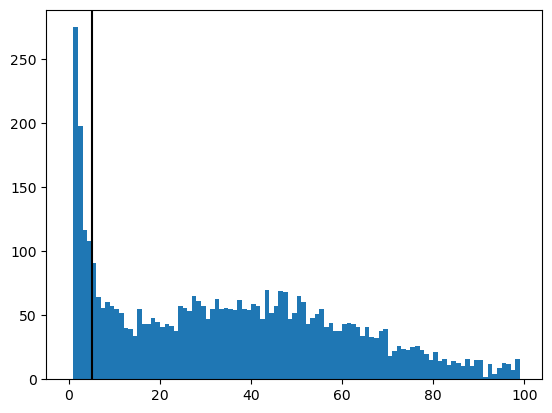

In [119]:
plt.hist(n_unique_umis, bins=range(100))
plt.axvline(min_umi_cutoff, c='black')
plt.show()

In [131]:
assignment_dict = {}
for cell in np.unique(combined_sample.loc[:, 'cell']):
    lineages, counts = np.unique(combined_sample.loc[combined_sample.loc[:, 'cell'] == cell, 'lineage'], return_counts=True)
    props = counts/np.sum(counts)
    if np.sum(counts) <= min_umi_cutoff:
        assignment_dict[cell] = np.array([])
    else:
        for i in range(len(lineages)):
            freq_cutoff = 1/(i+1)
            if np.sum(props > freq_cutoff) == i:
                assignment_dict[cell] = lineages[props > freq_cutoff]

(array([1.313e+03, 3.134e+03, 1.550e+02, 3.000e+00]),
 array([0., 1., 2., 3., 4.]),
 <BarContainer object of 4 artists>)

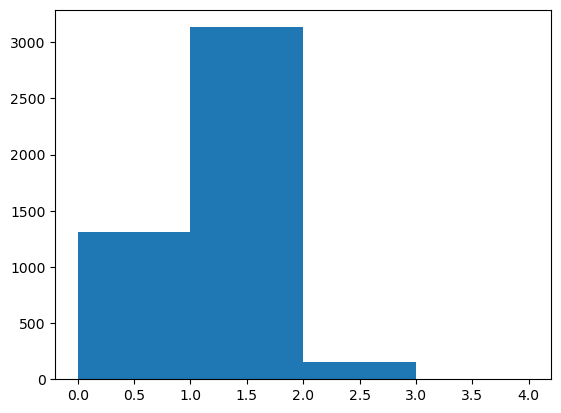

In [144]:
plt.hist([len(i) for i in assignment_dict.values()], bins=range(0,5))

In [145]:
lineage_singles = []
lineage_doublets = []
lineage_triplets = []
lineage_many = []

for lineage in [i for i in assignment_dict.values()]:
    if len(lineage) == 1:
        lineage_singles.append(lineage[0])
    elif len(lineage) == 2 and not any(np.array_equal(arr, lineage) for arr in lineage_doublets):
        lineage_doublets.append(lineage)
    elif len(lineage) == 3 and not any(np.array_equal(arr, lineage) for arr in lineage_triplets):
        lineage_triplets.append(lineage)
    elif len(lineage) > 3:
        lineage_many.append(lineage)

In [146]:
for lineages in lineage_doublets:
    if lineages[0] not in lineage_singles and lineages[1] not in lineage_singles:
        # neither barcode is singly assigned to a cell - just pick one and assign it
        for key, value in assignment_dict.items():
            if np.array_equal(value, lineages):
                assignment_dict[key] = np.array([lineages[0]])
    elif lineages[0] in lineage_singles and lineages[1] not in lineage_singles:
        # only one of the barcodes is assigned to other cells - assign these cells as that one
        for key, value in assignment_dict.items():
            if np.array_equal(value, lineages):
                assignment_dict[key] = np.array([lineages[0]])
    elif lineages[0] not in lineage_singles and lineages[1] in lineage_singles:
        # only one of the barcodes is assigned to other cells - assign these cells as that one
        for key, value in assignment_dict.items():
            if np.array_equal(value, lineages):
                assignment_dict[key] = np.array([lineages[1]])
    elif lineages[0] in lineage_singles and lineages[1] in lineage_singles:
        # both barcodes are seen in other signly assigned cells. set this cell as the barcode with the higher proportion
        for key, value in assignment_dict.items():
            if np.array_equal(value, lineages):\
                assignment_dict[key] = np.array([])

In [147]:
for lineages in lineage_triplets:
    if lineages[0] not in lineage_singles and lineages[1] not in lineage_singles and lineages[2] not in lineage_singles:
        # barcodes not found outside of this cell
        for key, value in assignment_dict.items():
            if np.array_equal(value, lineages):
                assignment_dict[key] = np.array([lineages[0]])
    elif lineages[0] in lineage_singles and lineages[1] not in lineage_singles and lineages[2] not in lineage_singles:
        # matches one barcode
        for key, value in assignment_dict.items():
            if np.array_equal(value, lineages):
                assignment_dict[key] = np.array([lineages[0]])
    elif lineages[0] not in lineage_singles and lineages[1] in lineage_singles and lineages[2] not in lineage_singles:
        # matches one barcode
        for key, value in assignment_dict.items():
            if np.array_equal(value, lineages):
                assignment_dict[key] = np.array([lineages[1]])
    elif lineages[0] not in lineage_singles and lineages[1] not in lineage_singles and lineages[2] in lineage_singles:
        # matches one barcode
        for key, value in assignment_dict.items():
            if np.array_equal(value, lineages):
                assignment_dict[key] = np.array([lineages[2]])
    elif lineages[0] in lineage_singles and lineages[1] in lineage_singles and lineages[2] not in lineage_singles:
        # matches two barcodes. set this cell as the barcode with the higher proportion
        for key, value in assignment_dict.items():
            if np.array_equal(value, lineages):
                assignment_dict[key] = np.array([])
    elif lineages[0] not in lineage_singles and lineages[1] in lineage_singles and lineages[2] in lineage_singles:
        # matches two barcodes. set this cell as the barcode with the higher proportion
        for key, value in assignment_dict.items():
            if np.array_equal(value, lineages):
                assignment_dict[key] = np.array([])
    elif lineages[0] in lineage_singles and lineages[1] not in lineage_singles and lineages[2] in lineage_singles:
        # matches two barcodes. set this cell as the barcode with the higher proportion
        for key, value in assignment_dict.items():
            if np.array_equal(value, lineages):
                assignment_dict[key] = np.array([])
    elif lineages[0] in lineage_singles and lineages[1] in lineage_singles and lineages[2] in lineage_singles:
        # matches three barcodes. set this cell as the barcode with the higher proportion
        for key, value in assignment_dict.items():
            if np.array_equal(value, lineages):
                assignment_dict[key] = np.array([])

In [149]:
np.sum([len(i) > 1 for i in assignment_dict.values()])

0

In [153]:
for cell in assignment_dict.keys():
    if len(assignment_dict[cell]) == 0:
        assignment_dict[cell] = 'none'
    else:
        assignment_dict[cell] = assignment_dict[cell][0]

In [154]:
assignment_dict

{'AAACCCACAAGTCATC': 'none',
 'AAACCCACACGTAACT': 'ATCTGGAAGTCGGGATGTGG',
 'AAACCCACAGTTGCGC': 'AATAGAGTAGGTCCAGCGTT',
 'AAACCCAGTTAGAAAC': 'TAATCTCGCCCAAAAACTAC',
 'AAACCCATCCGGTTCT': 'none',
 'AAACGAAAGACGCCCT': 'none',
 'AAACGAACATCCGTGG': 'AATCTGTCTAACGGGTAGCA',
 'AAACGAATCACTGTCC': 'AATACGTTGGTAAGTTTTTA',
 'AAACGAATCCTCAGGG': 'none',
 'AAACGCTAGCACTAGG': 'CCCCGTCGGGTTTTTTGTCG',
 'AAACGCTCATTGGCAT': 'none',
 'AAACGCTGTAATGATG': 'TGGGCAGGTTCATATGGTAG',
 'AAACGCTGTTTCCAAG': 'AATAGAGTAGGTCCAGCGTT',
 'AAACGCTTCACATACG': 'none',
 'AAAGGATAGACTTGTC': 'TGACGTACCCCAGTCCAGGC',
 'AAAGGATAGGTAGTCG': 'GGACGCGAACGGTGCGTTCG',
 'AAAGGATCAATTGCAC': 'none',
 'AAAGGATGTCCCGCAA': 'none',
 'AAAGGATGTGTGGTCC': 'none',
 'AAAGGATTCATCACAG': 'AATAGAGTAGGTCCAGCGTT',
 'AAAGGGCAGACTCCGC': 'TAATGTTCTAACTCTACCCT',
 'AAAGGGCGTCAACCTA': 'none',
 'AAAGGGCGTCACAATC': 'TACGCCGGCATTAGTCATAT',
 'AAAGGGCGTTATCTTC': 'TGGCTGACCACTCAGATCAA',
 'AAAGGGCGTTGTCAGT': 'ATCTGGAAGTCGGGATGTGG',
 'AAAGGGCTCCACAGGC': 'GCTCGGCAAGCTC

In [161]:
with open('lineage_assignment.txt', 'w') as f:
    for key,value in assignment_dict.items():
        f.write('%s\t%s\n' % (key, value))